# Epidemic model SIR 

In [335]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numba
from scipy import integrate

## Model diagram

The diagram below sums up the model SIR that we studied.

![](https://upload.wikimedia.org/wikipedia/commons/3/30/Diagram_of_SIR_epidemic_model_states_and_transition_rates.svg)


[Source: Wikipedia](https://upload.wikimedia.org/wikipedia/commons/3/30/Diagram_of_SIR_epidemic_model_states_and_transition_rates.svg)

## Problem formulation

In [336]:

np.random.seed(30)

N     = 200
beta  = 0.5
gamma = 0.04   
i0    = 1

healthy, infected, recovered = N - i0, i0, 0 # Health
t = 0.0
ts = [t]
S = [healthy]
I = [infected]
R = [recovered]


while  infected > 0:
    rate =  np.array([beta*healthy*infected/N, gamma*infected])
    dt = -np.log(np.random.rand(2)) / rate
    event = np.argmin(dt)
    t += dt[event] 
    if event ==0: 
        healthy -= 1
        infected += 1
    else: 
        infected -= 1
        recovered += 1
    ts.append(t)
    S.append(healthy) 
    I.append(infected) 
    R.append(recovered)
     


C:\Users\fedtm\AppData\Local\Temp\ipykernel_26680\4211958711.py:18: RuntimeWarning: divide by zero encountered in divide
  dt = -np.log(np.random.rand(2)) / rate


In [337]:
def run_sim_simple(seed = 30):
        
    np.random.seed(seed)
    N     = 200
    beta  = 0.5
    gamma = 0.04   
    i0    = 1

    healthy, infected, recovered = N - i0, i0, 0 # Health
    t = 0.0
    ts = [t]
    S = [healthy]
    I = [infected]
    R = [recovered]


    while  infected > 0:
        rate =  np.array([beta*healthy*infected/N, gamma*infected])
        dt = -np.log(np.random.rand(2)) / rate
        event = np.argmin(dt)
        t += dt[event] 
        if event ==0: 
            healthy -= 1
            infected += 1
        else: 
            infected -= 1
            recovered += 1
        ts.append(t)
        S.append(healthy) 
        I.append(infected) 
        R.append(recovered)
    return ts,S,I,R

In [338]:
def log_post(b, n_inf,C ,beta_max=5.0):
    if b <= 0 or b >= beta_max:
        return -np.inf
    return n_inf * np.log(b) - b * C # We can remove the non relevant non beta dependent for n_inf * np.log(b), hence alot is written out.      

beta_max = 5

def metropolis_hastings(n_inf,C ,beta_max,
                        n_iter=5000,
                        proposal_sd=0.2):
    rng = np.random.default_rng(30)

    samples = np.zeros(n_iter)

    beta = beta_max/2 # middle point

    accepted = 0

    for t in range(n_iter):

        beta_prop = beta + rng.normal(0, proposal_sd)
 
        log_alpha = log_post(beta_prop, n_inf, C,beta_max) - log_post(beta, n_inf, C,beta_max)
        
        if np.log(rng.uniform()) < log_alpha:
            beta = beta_prop
            accepted += 1
        samples[t] = beta

    print("Acceptance rate:",
          accepted / n_iter)

    return samples

In [339]:
ts,S,I,R=run_sim_simple()

dt = np.diff(ts)
S = np.array(S)
I = np.array(I)
C = np.sum(S[:-1]*I[:-1]/N * dt)    
n_inf    = int(np.sum(S[1:] < S[:-1])) 
beta_max = 5

n_iter = 10
burn = int(n_iter/10)
samples_beta_10 = metropolis_hastings(n_inf,C,beta_max,n_iter)
samples_beta_10 = samples_beta_10[burn:]

n_iter = 100
burn = int(n_iter/10)
samples_beta_100 = metropolis_hastings(n_inf,C,beta_max,n_iter)
samples_beta_100 = samples_beta_100[burn:]

n_iter = 1000
burn = int(n_iter/10)
samples_beta_1000 = metropolis_hastings(n_inf,C,beta_max,n_iter)
samples_beta_1000 = samples_beta_1000[burn:]


Acceptance rate: 0.5
Acceptance rate: 0.26
Acceptance rate: 0.229


C:\Users\fedtm\AppData\Local\Temp\ipykernel_26680\2385302247.py:19: RuntimeWarning: divide by zero encountered in divide
  dt = -np.log(np.random.rand(2)) / rate


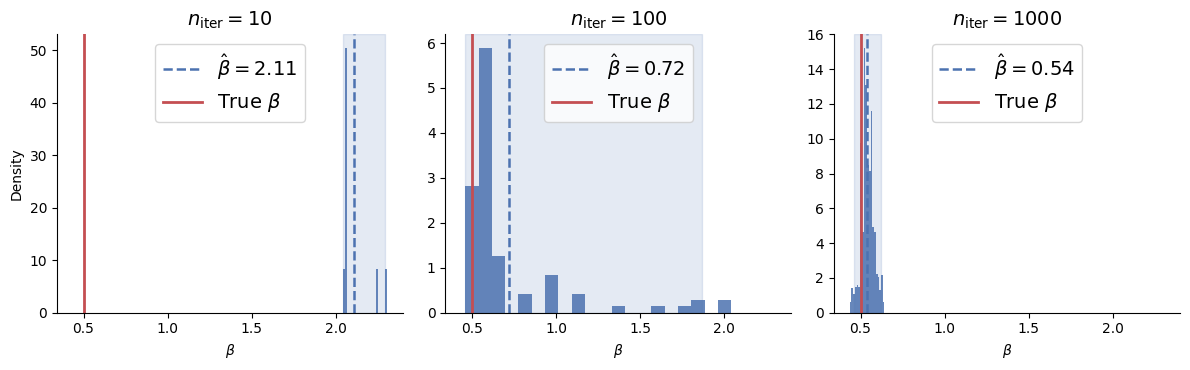

In [352]:

chains = [
    (samples_beta_10,   r"$n_{\mathrm{iter}}=10$"),
    (samples_beta_100,  r"$n_{\mathrm{iter}}=100$"),
    (samples_beta_1000, r"$n_{\mathrm{iter}}=1000$"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True)

for ax, (s, label) in zip(axes, chains):
    x = s
    ax.hist(x, bins=20, density=True, color="#4C72B0", alpha=0.85)

    mean = x.mean()
    lo, hi = np.percentile(x, [2.5, 97.5]) # confidence interval
    ax.axvspan(lo, hi, color="#4C72B0", alpha=0.15)         
    ax.axvline(mean, color="#4C72B0", lw=1.8, ls="--",
               label=fr"$\hat\beta={mean:.2f}$")
    ax.axvline(beta, color="#C44E52", lw=2, label=r"True $\beta$")

    ax.set_title(label,fontsize=14)
    ax.set_xlabel(r"$\beta$")
    ax.legend(fontsize=14, loc="upper center")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()
# fig.savefig("beta_posterior.pdf", bbox_inches="tight")

# Recovered can be in effected again +
# Infected can die instead of begin recovered 

C:\Users\fedtm\AppData\Local\Temp\ipykernel_26680\1106154474.py:22: RuntimeWarning: divide by zero encountered in divide
  dt = -np.log(np.random.rand(4)) / rate # 0 = infected, 1= recovered, 2 = dø, #3 =  recovered -> suseptible # 4 vacciancted


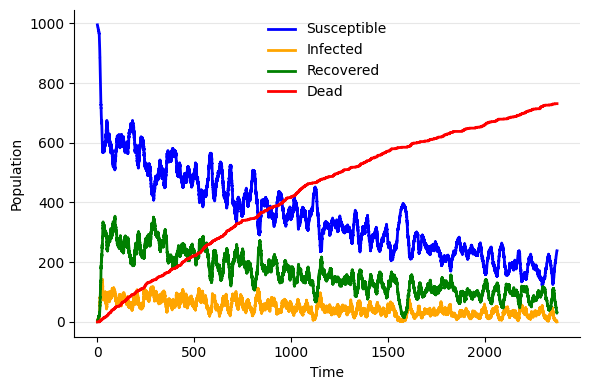

In [371]:


def Run_sim(seed =30):
    np.random.seed(seed)      
    N     = 1000
    beta  = 0.5  # rates for infection
    gamma = 0.3  # rate for recovery
    mu = 0.0068 # rate for death
    eta = 0.09 # rate for be suseptible again
    i0    = 5

    healthy, infected, recovered,death = N - i0, i0, 0,0 # Health
    t = 0.0
    ts = [t]
    S = [healthy]
    I = [infected]
    R = [recovered]
    D = [death]


    while  infected > 0:
        N = healthy + recovered + infected
        rate =  np.array([beta*healthy*infected/N, gamma*infected,mu*infected,eta*recovered])
        dt = -np.log(np.random.rand(4)) / rate # 0 = infected, 1= recovered, 2 = dø, #3 =  recovered -> suseptible # 4 vacciancted
        event = np.argmin(dt) # next time event
        t += dt[event] 
        if event ==0: 
            healthy -= 1
            infected += 1
        if event == 1:
            infected -= 1
            recovered += 1
        if event == 2: 
            infected -= 1
            death += 1
        if event == 3:
            healthy +=1 
            recovered -=1
        ts.append(t)
        S.append(healthy) 
        I.append(infected) 
        R.append(recovered)
        D.append(death)
    #    RV.append(vaccinated)
    return ts,S,I,R,D
     
seed = 30

ts,S,I,R,D = Run_sim(seed)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ts,S, color="blue", lw=2, label="Susceptible")
ax.plot(ts,I, color="orange", lw=2, label="Infected")
ax.plot(ts,R, color="green", lw=2, label="Recovered")
ax.plot(ts,D, color="red", lw=2, label="Dead")
#ax.plot(RV, color ="#FFE73D",lw=2, label="Vaccinate")

#ax.set_title("Seed = %.i" % seed, fontsize=25)

ax.set_xlabel("Time")
ax.set_ylabel("Population")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

What is the likelihood that the disease will disappear within?
- Variance reduction


In [316]:
def Run_sim():
      
    N     = 1000
    beta  = 0.5  # rates for infection
    gamma = 0.3  # rate for recovery
    mu = 0.0068 # rate for death
    eta = 0.03 # rate for be suseptible again
    i0    = 5

    healthy, infected, recovered,death = N - i0, i0, 0,0 # Health
    t = 0.0
    ts = [t]
    S = [healthy]
    I = [infected]
    R = [recovered]
    D = [death]


    while  infected > 0:
        N = healthy + recovered + infected
        rate =  np.array([beta*healthy*infected/N, gamma*infected,mu*infected,eta*recovered])
        dt = -np.log(np.random.rand(4)) / rate # 0 = infected, 1= recovered, 2 = dø, #3 =  recovered -> suseptible # 4 vacciancted
        event = np.argmin(dt) # next time event
        t += dt[event] 
        if event ==0: 
            healthy -= 1
            infected += 1
        if event == 1:
            infected -= 1
            recovered += 1
        if event == 2: 
            infected -= 1
            death += 1
        if event == 3:
            healthy +=1 
            recovered -=1
        ts.append(t)
        S.append(healthy) 
        I.append(infected) 
        R.append(recovered)
        D.append(death)
    #    RV.append(vaccinated)
    return ts

In [319]:
def P_T_monte_carlo_sim_mean(N =500,seed = 30):
    np.random.seed(seed)
    End_time = np.zeros(N)
    for _ in range(N):
        ts = Run_sim()
        End_time[_]= np.max(ts)
        print(_)
    X= np.mean(End_time)

    return X,np.var(End_time,ddof=1)

In [320]:
mean, var = P_T_monte_carlo_sim_mean()

C:\Users\fedtm\AppData\Local\Temp\ipykernel_26680\442846997.py:22: RuntimeWarning: divide by zero encountered in divide
  dt = -np.log(np.random.rand(4)) / rate # 0 = infected, 1= recovered, 2 = dø, #3 =  recovered -> suseptible # 4 vacciancted


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
def P_T_monte_carlo(T_value,N =1000,seed = 30):
    np.random.seed(seed)
    End_time = np.zeros(N)
    for _ in range(N):
        ts = Run_sim()
        if np.max(ts) <= T_value:
            End_time[_]= 1
    X= np.mean(End_time)
    return X,np.var(End_time,ddof=1) 

In [330]:
interval = 500
T_grid = np.linspace(1, 1500, interval)
means = np.zeros(interval)
vars = np.zeros_like(means)
for i in range(interval): 
        mean,var = P_T_monte_carlo(T_grid[i],50)
        means[i]= mean
        vars[i] = var
        print(i)

C:\Users\fedtm\AppData\Local\Temp\ipykernel_26680\442846997.py:22: RuntimeWarning: divide by zero encountered in divide
  dt = -np.log(np.random.rand(4)) / rate # 0 = infected, 1= recovered, 2 = dø, #3 =  recovered -> suseptible # 4 vacciancted


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

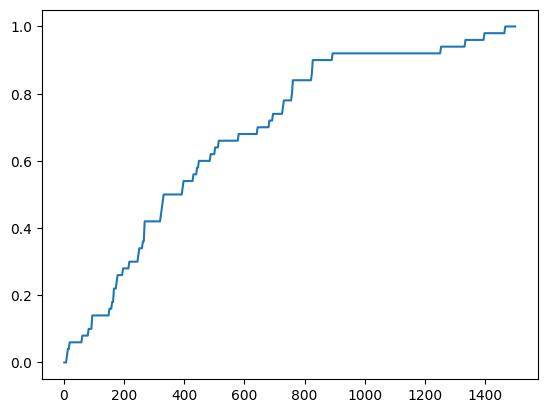

In [ ]:
plt.plot(T_grid,means) # emerical CDF 

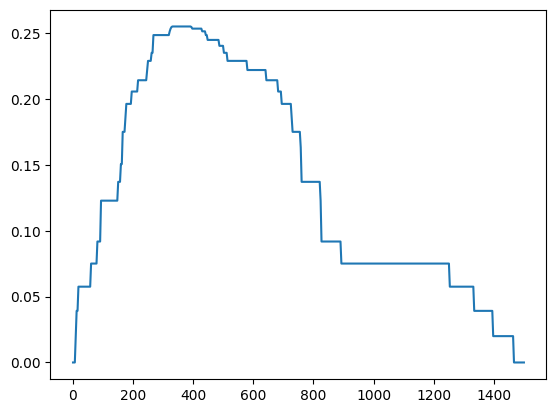

In [ ]:
plt.plot(T_grid,vars) # variane over  emerical CDF , we see high variance close to mean

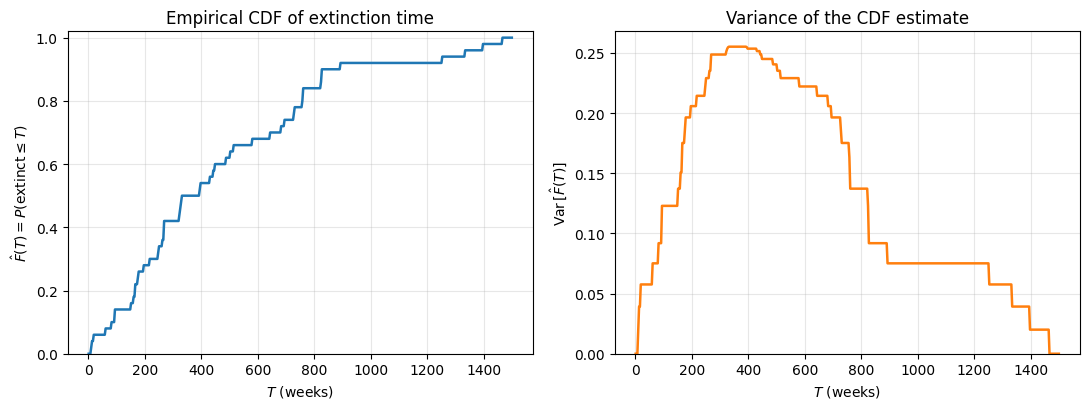

In [373]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Left: empirical CDF
axes[0].plot(T_grid, means, color="C0", lw=1.8)
axes[0].set_xlabel(r"$T$ (weeks)")
axes[0].set_ylabel(r"$\hat{F}(T) = P(\text{extinct} \leq T)$")
axes[0].set_title("Empirical CDF of extinction time")
axes[0].set_ylim(0, 1.02)
axes[0].grid(alpha=0.3)

# Right: variance of the empirical CDF estimate
axes[1].plot(T_grid, vars, color="C1", lw=1.8)
axes[1].set_xlabel(r"$T$ (weeks)")
axes[1].set_ylabel(r"$\mathrm{Var}\,[\hat{F}(T)]$")
axes[1].set_title("Variance of the CDF estimate")
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.savefig("extinction_cdf.pdf", bbox_inches="tight")  # vector, nice for LaTeX
plt.show()

## We pick T = 400 and try variance reduction

#  Importance sampling

In [ ]:
T = 400

def is_estimate_7(a,N,sigma=1):
    Y = np.random.normal(a,sigma,size=N)    
    h = lambda x: x>a
    X = h(Y)*ss.norm.pdf(Y,loc=0,scale=1)/ss.norm.pdf(Y,loc=a,scale=sigma)
    return np.mean(X),np.var(X,ddof=1)